# Layout-optimized chunking

Reads every PDF in `data/raw/kvaliteket/` and splits each into chunks along its headings. Sections longer than the chunk size are split further by size, and tables stay in the section they belong to.

The PDFs are real HR documents and notebook outputs are saved in this file: only print counts and statistics here, never chunk text.

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src" / "backend" / "ai"))
sys.path.insert(0, str(REPO_ROOT / "src" / "backend" / "ai" / "chunking"))

from pdf_reader import read_all_pdfs
from fixed_chunking import DEFAULT_CHUNK_SIZE
from layout_chunking import chunk_by_layout

In [2]:
documents = read_all_pdfs(REPO_ROOT / "data" / "raw" / "kvaliteket")

chunks = [
    chunk
    for document in documents
    for chunk in chunk_by_layout(document["words"], document["source_pdf"])
]

In [3]:
import re
from statistics import mean, median, pstdev

words_per_chunk = [
    len(chunk["text"].split())
    for chunk in chunks
]
chunks_from_split_sections = [
    chunk
    for chunk in chunks
    if re.search(r"\(\d+/\d+\)$", chunk["heading"])
]
tiny_chunk_word_limit = 3

print(
    f"{len(documents)} documents -> {len(chunks)} chunks "
    f"(max chunk size {DEFAULT_CHUNK_SIZE})"
)

print(f"Total words: {sum(words_per_chunk)}")
print(f"Average chunks per document: {len(chunks) / len(documents):.1f}")
print(f"Chunks from sections that were split by size: {len(chunks_from_split_sections)}")
print(f"Chunks with at most {tiny_chunk_word_limit} words: {sum(words <= tiny_chunk_word_limit for words in words_per_chunk)}")

print("\nWords per chunk:")
print(f"  min:    {min(words_per_chunk)}")
print(f"  max:    {max(words_per_chunk)}")
print(f"  mean:   {mean(words_per_chunk):.1f}")
print(f"  median: {median(words_per_chunk):.1f}")
print(f"  std:    {pstdev(words_per_chunk):.1f}")

137 documents -> 1532 chunks (max chunk size 80)
Total words: 83831
Average chunks per document: 11.2
Chunks from sections that were split by size: 996
Chunks with at most 3 words: 41

Words per chunk:
  min:    1
  max:    89
  mean:   54.7
  median: 62.0
  std:    22.5


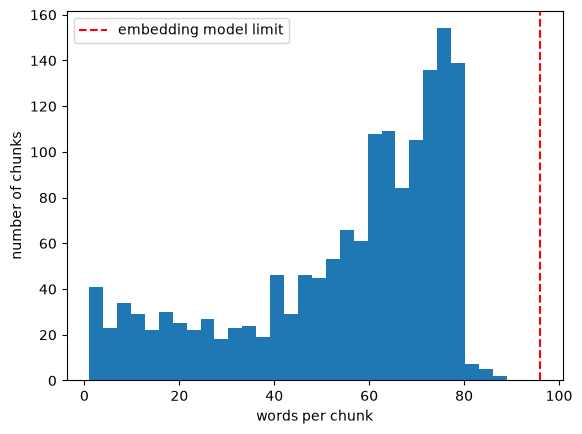

In [4]:
import matplotlib.pyplot as plt

EMBEDDING_MODEL_WORD_LIMIT = 96

plt.hist(words_per_chunk, bins=30)
plt.axvline(EMBEDDING_MODEL_WORD_LIMIT, color="red", linestyle="--", label="embedding model limit")
plt.xlabel("words per chunk")
plt.ylabel("number of chunks")
plt.legend()
plt.show()